1. Uvod
Opis problema:
Ovaj projekt rješava problem klasifikacije. Cilj je predvidjeti preživljavanje putnika na Titanicu na temelju dostupnih demografskih i putničkih podataka (poput starosti, spola, klase karte). Važnost ovog problema leži u demonstraciji kako se algoritmi strojnog učenja mogu koristiti za analizu povijesnih podataka i donošenje predikcija o ishodima na temelju uzoraka u podacima, što ima široku primjenu u zdravstvu, osiguranju i procjeni rizika.

Ciljevi projekta:

1) Istražiti i obraditi sirove podatke o putnicima.

2) Identificirati ključne značajke koje najviše utječu na vjerojatnost preživljavanja.

3) Trenirati i usporediti dva različita modela klasifikacije (Logistička regresija i Random Forest).

4) Evaluirati modele korištenjem kros-validacije i odgovarajućih metrika (Točnost, F1 score, Matrica zabune) te odabrati optimalan model.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

print("Biblioteke su uspješno učitane!")

Biblioteke su uspješno učitane!


2. Prikupljanje i obrada podataka
Prikupljanje podataka: Podaci su preuzeti iz biblioteke seaborn koja sadrži izvorni Titanic dataset. Opisuju putnike, njihove demografske podatke i informaciju jesu li preživjeli.

Čišćenje podataka:

- Uklanjamo kolonu deck (previše nedostajućih vrijednosti) i redundantne kolone poput alive i who.

- Popunjavamo nedostajuće vrijednosti u koloni age pomoću medijana.

- Kodiramo spol (sex) i luku ukrcaja (embarked) u brojeve kako bi ih model mogao razumjeti.

- Normaliziramo numeričke podatke (skaliranje)

In [2]:
df = sns.load_dataset('titanic')

df = df.drop(['deck', 'alive', 'who', 'adult_male', 'class', 'embark_town'], axis=1)

df['age'] = df['age'].fillna(df['age'].median())
df = df.dropna(subset=['embarked'])

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

print("Očišćeni podaci (prvih 5 redova):")
df.head()

Očišćeni podaci (prvih 5 redova):


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


3. Analiza značajki
- Istraživačka analiza podataka (EDA): Vizualizirat ćemo distribuciju preživljavanja u ovisnosti o spolu putnika te prikazati korelacijsku matricu svih numeričkih značajki kako bismo uočili koje su varijable najviše povezane s preživljavanjem.

- Odabir značajki: Na temelju analize i korelacijske matrice, za treniranje modela odabiremo značajke: pclass (klasa), sex (spol), age (dob), sibsp (braća/supružnici), parch (roditelji/djeca), fare (cijena karte) i embarked (luka ukrcaja). Redundantne i tekstualne stupce smo već eliminirali.

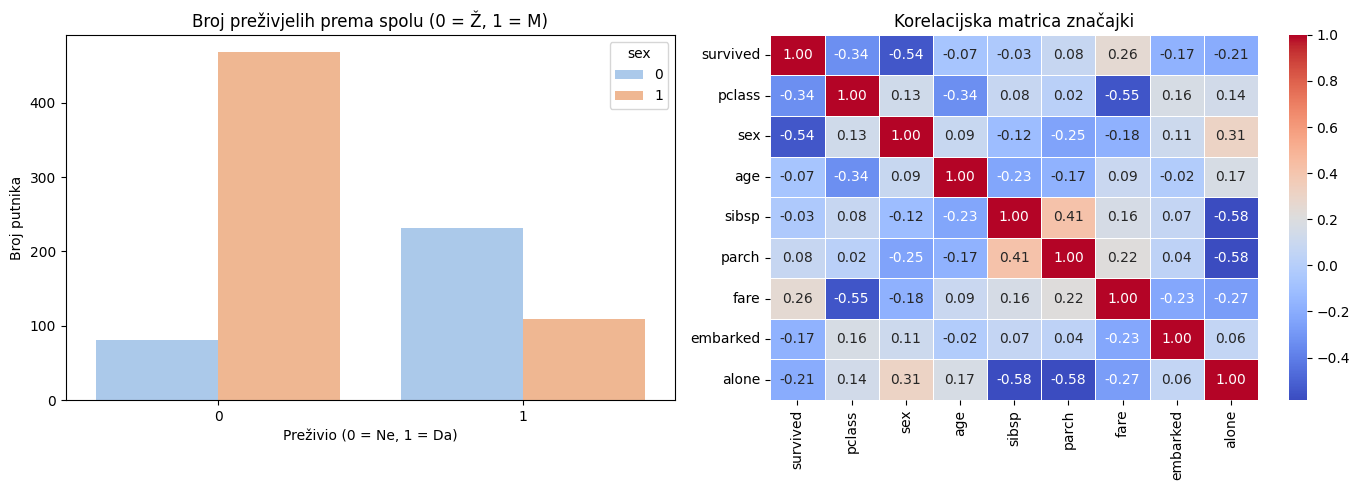


Konačan popis odabranih značajki za model:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


In [3]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='survived', hue='sex', data=df, palette='pastel')
plt.title('Broj preživjelih prema spolu (0 = Ž, 1 = M)')
plt.xlabel('Preživio (0 = Ne, 1 = Da)')
plt.ylabel('Broj putnika')

plt.subplot(1, 2, 2)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelacijska matrica značajki')

plt.tight_layout()
plt.show()

X = df.drop('survived', axis=1)
y = df['survived']

print("\nKonačan popis odabranih značajki za model:")
print(list(X.columns))

4. Izbor i implementacija modela
- Izbor modela: Koristit ćemo dva različita modela za klasifikaciju: Logističku regresiju (kao jednostavan, linearni osnovni model) i Random Forest / Slučajnu šumu (moćan ansambl model koji koristi više stabala odluka).

- Priprema podataka: Prije treniranja, podatke dijelimo na skup za treniranje (80%) i skup za testiranje (20%). Također provodimo normalizaciju (skaliranje) značajki pomoću StandardScaler funkcije kako bi algoritmi bolje i brže radili.

- Kros-validacija: Za ocjenu robusnosti modela implementirana je kros-validacija s 5 preklopa (5-fold) na podacima za treniranje.

In [4]:
X = df.drop('survived', axis=1)
y = df['survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

cv_log = cross_val_score(log_model, X_train, y_train, cv=5, scoring='accuracy')
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Prosječna točnost kros-validacije (Logistička regresija): {cv_log.mean():.4f}")
print(f"Prosječna točnost kros-validacije (Random Forest): {cv_rf.mean():.4f}")

Prosječna točnost kros-validacije (Logistička regresija): 0.8045
Prosječna točnost kros-validacije (Random Forest): 0.8158


5. Evaluacija modela
- Evaluacija performansi: Modeli su evaluirani na testnom skupu podataka koji nisu vidjeli tijekom treniranja. Korištene su metrike: točnost (Accuracy), F1 score, preciznost (Precision) i odziv (Recall) kroz klasifikacijsko izvješće. Također, vizualizirana je matrica zabune.

- Usporedba modela: Uspoređujemo rezultate kako bismo donijeli konačan zaključak o tome koji algoritam bolje generalizira pravila iz ovih podataka i daje točnija predviđanja.

=== LOGISTIČKA REGRESIJA ===
Točnost: 0.8033707865168539
Izvješće klasifikacije:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84       109
           1       0.74      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.80      0.79       178
weighted avg       0.81      0.80      0.80       178


=== RANDOM FOREST ===
Točnost: 0.7471910112359551
Izvješće klasifikacije:
               precision    recall  f1-score   support

           0       0.81      0.76      0.79       109
           1       0.66      0.72      0.69        69

    accuracy                           0.75       178
   macro avg       0.74      0.74      0.74       178
weighted avg       0.75      0.75      0.75       178



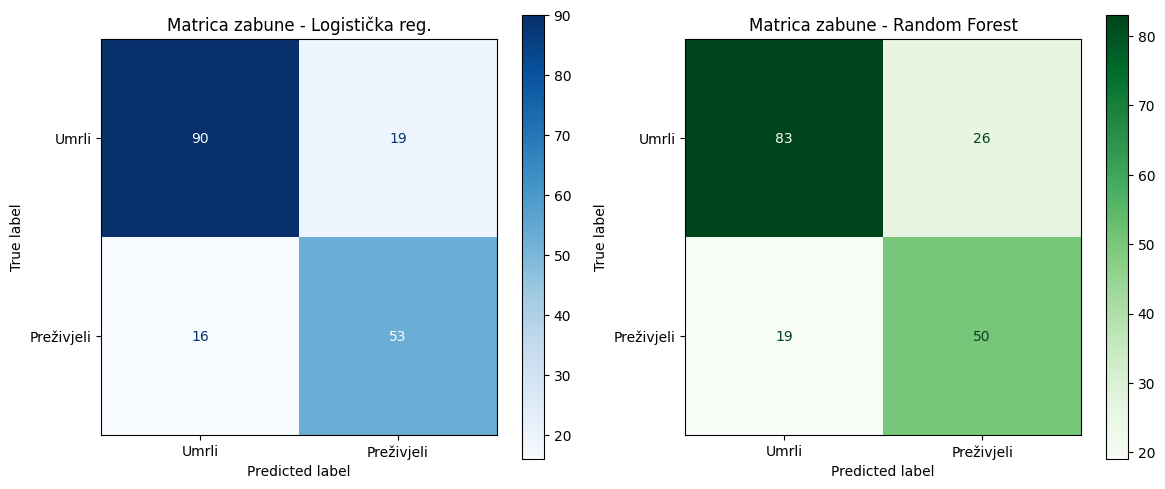


ZAKLJUČAK: Model s najboljim performansama na testnom skupu je Logistička Regresija.


In [5]:
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("=== LOGISTIČKA REGRESIJA ===")
print("Točnost:", accuracy_score(y_test, y_pred_log))
print("Izvješće klasifikacije:\n", classification_report(y_test, y_pred_log))

print("\n=== RANDOM FOREST ===")
print("Točnost:", accuracy_score(y_test, y_pred_rf))
print("Izvješće klasifikacije:\n", classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log), display_labels=["Umrli", "Preživjeli"]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Matrica zabune - Logistička reg.')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=["Umrli", "Preživjeli"]).plot(ax=ax[1], cmap='Greens')
ax[1].set_title('Matrica zabune - Random Forest')

plt.tight_layout()
plt.show()

best_model = "Random Forest" if accuracy_score(y_test, y_pred_rf) > accuracy_score(y_test, y_pred_log) else "Logistička Regresija"
print(f"\nZAKLJUČAK: Model s najboljim performansama na testnom skupu je {best_model}.")